## 1단계. 원본 데이터 로드 및 구조 진단

GitHub에 공개된 AdventureWorks 엑셀 파일에서 분석에 필요한 5개 시트를 모두 불러옵니다.
각 테이블의 행/열 수와 결측치 현황을 먼저 파악하여 데이터 품질을 초기 진단합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

경고_무시 = __import__('warnings')
경고_무시.filterwarnings('ignore')

url = "https://github.com/microsoft/powerbi-desktop-samples/raw/main/AdventureWorks%20Sales%20Sample/AdventureWorks%20Sales.xlsx"

판매_원본 = pd.read_excel(url, sheet_name="Sales_data")
고객_원본 = pd.read_excel(url, sheet_name="Customer_data")
상품_원본 = pd.read_excel(url, sheet_name="Product_data")
날짜_원본 = pd.read_excel(url, sheet_name="Date_data")
지역_원본 = pd.read_excel(url, sheet_name="Sales Territory_data")

print("=== 각 테이블 크기 ===")
for 이름, 테이블 in [("판매", 판매_원본), ("고객", 고객_원본), ("상품", 상품_원본), ("날짜", 날짜_원본), ("지역", 지역_원본)]:
    print(f"{이름}: {테이블.shape[0]:,}행 × {테이블.shape[1]}열")

=== 각 테이블 크기 ===
판매: 121,253행 × 15열
고객: 18,485행 × 7열
상품: 397행 × 9열
날짜: 1,461행 × 7열
지역: 11행 × 4열


### 1.1 결측치 초기 진단

각 테이블에서 결측치가 있는 컬럼만 추출하여 출력합니다.
이 단계는 어떤 컬럼을 어떤 방식으로 처리해야 하는지 전략을 세우기 위한 것입니다.

In [4]:
for 이름, 테이블 in [("판매", 판매_원본), ("고객", 고객_원본), ("상품", 상품_원본)]:
    결측_컬럼 = 테이블.isnull().sum()
    결측_컬럼 = 결측_컬럼[결측_컬럼 > 0]
    if len(결측_컬럼) > 0:
        print(f"\n[{이름} 테이블 결측치]")
        print(결측_컬럼.to_string())
    else:
        print(f"\n[{이름} 테이블]: 결측치 없음")


[판매 테이블 결측치]
ShipDateKey    2113

[고객 테이블]: 결측치 없음

[상품 테이블 결측치]
Color    56


## 2단계. 테이블 병합 

> **왜 병합을 먼저 하는가?**
> 이상치 제거와 같은 정제 작업은 분석에 실제 사용될 컬럼(`Standard Cost`, `Category`, `Country` 등)이
> 모두 존재하는 상태에서 수행해야 합니다. 병합 전에 정제를 하면 없는 컬럼을 기준으로 필터링하거나,
> 나중에 생길 데이터 왜곡을 미리 제거하지 못하는 문제가 발생합니다.

판매 테이블을 기준으로 날짜, 상품, 지역, 고객 정보를 순서대로 `LEFT JOIN` 방식으로 연결합니다.

In [5]:
df = 판매_원본.copy()

df = pd.merge(df, 날짜_원본[["DateKey", "Month", "Fiscal Year"]], left_on="OrderDateKey", right_on="DateKey", how="left")

df = pd.merge(df, 상품_원본[["ProductKey", "Category", "Subcategory", "Model", "Standard Cost"]], on="ProductKey", how="left")

df = pd.merge(df, 지역_원본[["SalesTerritoryKey", "Region", "Country", "Group"]], on="SalesTerritoryKey", how="left")

df = pd.merge(df, 고객_원본[["CustomerKey", "Customer"]], on="CustomerKey", how="left")

print(f"병합 완료: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"컬럼 목록: {df.columns.tolist()}")

병합 완료: 121,253행 × 26열
컬럼 목록: ['SalesOrderLineKey', 'ResellerKey', 'CustomerKey', 'ProductKey', 'OrderDateKey', 'DueDateKey', 'ShipDateKey', 'SalesTerritoryKey', 'Order Quantity', 'Unit Price', 'Extended Amount', 'Unit Price Discount Pct', 'Product Standard Cost', 'Total Product Cost', 'Sales Amount', 'DateKey', 'Month', 'Fiscal Year', 'Category', 'Subcategory', 'Model', 'Standard Cost', 'Region', 'Country', 'Group', 'Customer']


## 3단계. 결측치 처리

병합 이후 발생한 결측치를 컬럼 성격에 맞게 처리합니다.

| 컬럼 | 처리 방법 | 이유 |
|---|---|---|
| `ShipDateKey` | `DueDateKey` 값으로 대체 | 미배송 주문이지만 예정일이 존재함. 행 삭제 시 유효한 주문 데이터 손실 |
| `Customer` | `[Reseller]` 문자열로 대체 | CustomerKey가 없는 거래는 B2B 도매 채널임 |
| 나머지 핵심 수치 컬럼 | 해당 행 제거 | `Sales Amount` 등 모델 타겟 변수의 결측은 대체 불가 |

> ⚠️ 기존 노트북에서는 `ShipDateKey` 결측치 2,113건을 바로 `dropna`로 삭제했습니다.
> 그러나 이 행들은 유효한 주문 거래이므로, 예정 배송일(`DueDateKey`)로 대체하여 보존합니다.

In [6]:
df["ShipDateKey"] = df["ShipDateKey"].fillna(df["DueDateKey"])

df["Customer"] = df["Customer"].fillna("[Reseller]")

df["is_reseller"] = (df["CustomerKey"] == -1).astype(int)

핵심_수치_컬럼 = ["Order Quantity", "Unit Price", "Standard Cost", "Sales Amount"]
이전_행수 = len(df)
df = df.dropna(subset=핵심_수치_컬럼)
이후_행수 = len(df)

print(f"결측치로 제거된 행 수: {이전_행수 - 이후_행수:,}건")
print(f"처리 후 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")

결측치로 제거된 행 수: 0건
처리 후 데이터 크기: 121,253행 × 27열


## 4단계. 중복 데이터 제거

동일한 거래가 여러 번 기록된 경우 분석의 신뢰도를 떨어뜨립니다.
모든 컬럼 값이 완전히 동일한 행을 중복으로 판단하고 제거합니다.

In [7]:
이전_행수 = len(df)
df = df.drop_duplicates()
이후_행수 = len(df)

print(f"제거된 중복 행 수: {이전_행수 - 이후_행수:,}건")
print(f"중복 제거 후 데이터 크기: {df.shape[0]:,}행")

제거된 중복 행 수: 0건
중복 제거 후 데이터 크기: 121,253행


## 5단계. 이상치 탐지 및 제거 (IQR 방식)

> **왜 이 단계를 병합 이후에 수행하는가?**
> 이상치 기준이 되는 `Sales Amount`와 `Order Quantity`는 판매 테이블에 존재하지만,
> 실제 분석에서 사용하는 `Standard Cost`는 상품 테이블에서 병합되어 옵니다.
> 병합 이전에 이상치를 제거하면 전체 데이터 분포가 아닌 불완전한 상태에서 필터링이 이루어집니다.

**IQR (사분위수 범위) 방식:**

$$IQR = Q3 - Q1$$
$$\\text{하한} = Q1 - 1.5 \\times IQR$$
$$\\text{상한} = Q3 + 1.5 \\times IQR$$

매출 예측 모델에 직접적인 영향을 미치는 `Order Quantity`(주문 수량)와 `Sales Amount`(매출 금액)를 대상으로 적용합니다.

In [9]:
def IQR_이상치_제거(데이터프레임, 컬럼명):
    Q1 = 데이터프레임[컬럼명].quantile(0.25)
    Q3 = 데이터프레임[컬럼명].quantile(0.75)
    IQR = Q3 - Q1
    하한 = Q1 - 1.5 * IQR
    상한 = Q3 + 1.5 * IQR
    필터 = (데이터프레임[컬럼명] >= 하한) & (데이터프레임[컬럼명] <= 상한)
    print(f"  [{컬럼명}] 범위: {하한:.2f} ~ {상한:.2f} → 제거된 행: {(~필터).sum():,}건")
    return 데이터프레임[필터]

이전_행수 = len(df)
print("이상치 제거 진행:")
df = IQR_이상치_제거(df, "Order Quantity")
df = IQR_이상치_제거(df, "Sales Amount")
이후_행수 = len(df)

print(f"\n이상치 제거 전: {이전_행수:,}행")
print(f"이상치 제거 후: {이후_행수:,}행")
print(f"총 제거된 행: {이전_행수 - 이후_행수:,}건 ({(이전_행수 - 이후_행수)/이전_행수*100:.1f}%)")

이상치 제거 진행:
  [Order Quantity] 범위: -0.50 ~ 3.50 → 제거된 행: 11,385건
  [Sales Amount] 범위: -1021.59 ~ 1756.48 → 제거된 행: 9,707건

이상치 제거 전: 105,442행
이상치 제거 후: 84,350행
총 제거된 행: 21,092건 (20.0%)


## 6단계. 범주형 변수 인코딩 및 날짜 변환

머신러닝 모델은 문자열을 직접 처리할 수 없으므로, 범주형 컬럼을 숫자형으로 변환합니다.

- **`Month`** → `Month_num`: 월 이름을 1~12 정수로 변환 (계절성 피처)
- **`Category`** → `Category_enc`: LabelEncoder로 숫자 인코딩
- **`Country`** → `Country_enc`: LabelEncoder로 숫자 인코딩

In [10]:
월_순서 = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

df["Month_num"] = df["Month"].apply(lambda x: 월_순서.index(x) + 1 if x in 월_순서 else 0)

인코더_카테고리 = LabelEncoder()
인코더_국가 = LabelEncoder()

df["Category_enc"] = 인코더_카테고리.fit_transform(df["Category"].astype(str))
df["Country_enc"] = 인코더_국가.fit_transform(df["Country"].astype(str))

print("카테고리 인코딩 매핑:")
for 코드, 이름 in enumerate(인코더_카테고리.classes_):
    print(f"  {코드} → {이름}")

print("\n국가 인코딩 매핑:")
for 코드, 이름 in enumerate(인코더_국가.classes_):
    print(f"  {코드} → {이름}")

카테고리 인코딩 매핑:
  0 → Accessories
  1 → Bikes
  2 → Clothing
  3 → Components

국가 인코딩 매핑:
  0 → Australia
  1 → Canada
  2 → France
  3 → Germany
  4 → United Kingdom
  5 → United States


## 7단계. 탐색적 데이터 분석 (EDA)

> 정제가 완료된 데이터를 기반으로 EDA를 수행합니다.
> 정제 전 원본 데이터로 EDA를 하면 이상치와 결측치가 시각화를 왜곡시킵니다.

### 7.1 핵심 수치 변수 기초 통계

In [23]:
통계_요약 = df[["Order Quantity", "Unit Price", "Standard Cost", "Sales Amount"]].describe()
print(통계_요약.round(2).to_string())

       Order Quantity  Unit Price  Standard Cost  Sales Amount
count        84350.00    84350.00       84350.00      84350.00
mean             1.30      211.97         177.28        277.64
std              0.61      350.37         304.14        433.41
min              1.00        1.37           0.86          1.37
25%              1.00        9.99           6.92          9.99
50%              1.00       34.99          13.88         35.00
75%              1.00      323.99         294.58        419.46
max              3.00     1700.99        1912.15       1749.59


### 7.2 매출 금액 분포 시각화

매출 금액(`Sales Amount`)의 분포를 히스토그램으로 시각화합니다.
평균(빨간 점선)과 중앙값(초록 실선)의 위치 차이를 통해 분포의 왜도를 파악합니다.

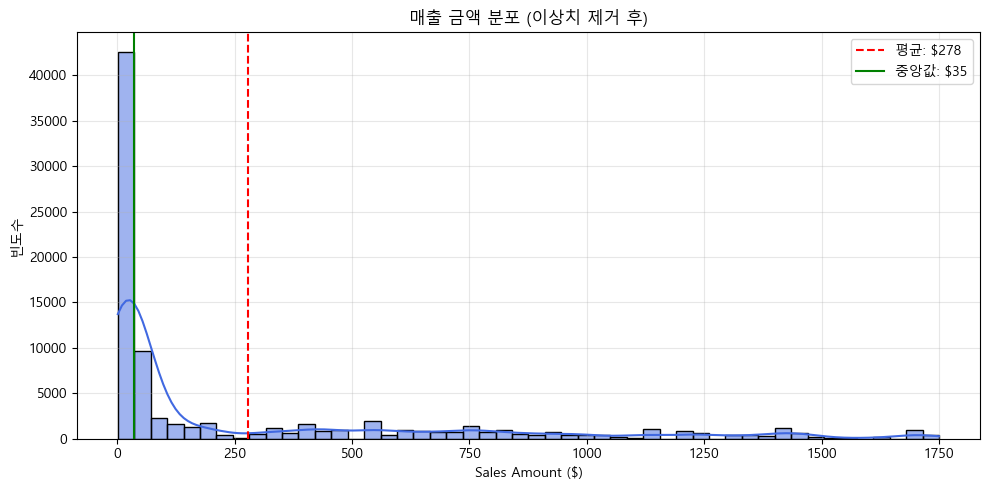

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Sales Amount"], bins=50, kde=True, color="royalblue")
plt.axvline(df["Sales Amount"].mean(), color="red", linestyle="--", label=f'평균: ${df["Sales Amount"].mean():,.0f}')
plt.axvline(df["Sales Amount"].median(), color="green", linestyle="-", label=f'중앙값: ${df["Sales Amount"].median():,.0f}')
plt.title("매출 금액 분포 (이상치 제거 후)")
plt.xlabel("Sales Amount ($)")
plt.ylabel("빈도수")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 시간 및 지역별 매출 분석

회계연도별, 국가별 총 매출을 집계하여 시간적·지리적 매출 패턴을 파악합니다.

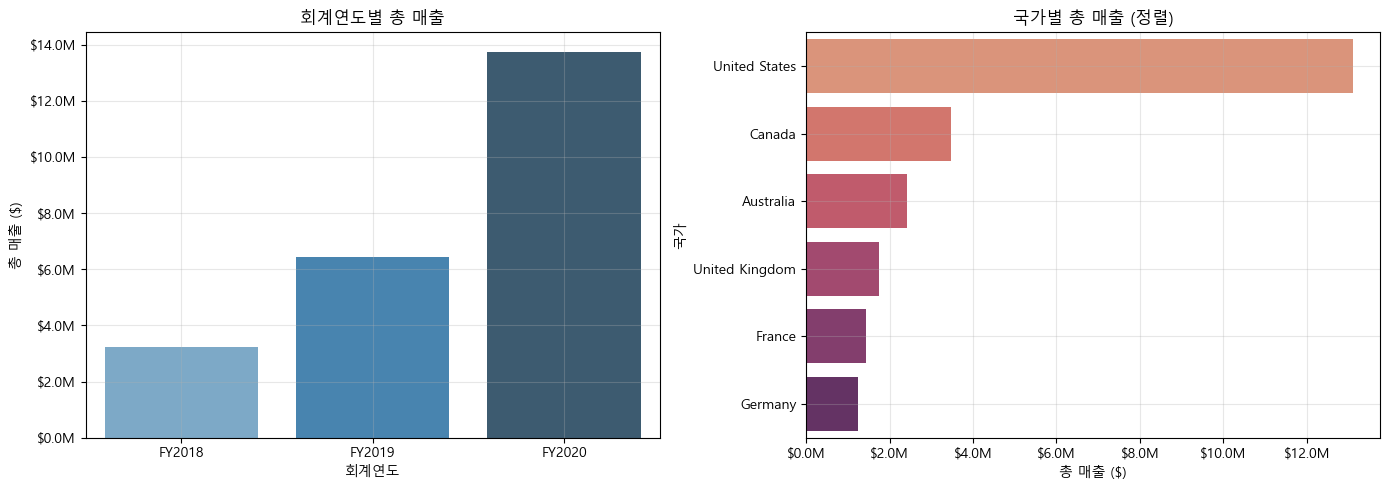


국가별 매출 상세:
       Country  Sales Amount
 United States  1.309464e+07
        Canada  3.472328e+06
     Australia  2.420952e+06
United Kingdom  1.746622e+06
        France  1.438919e+06
       Germany  1.245210e+06


In [25]:
시각화_연도 = df.groupby("Fiscal Year")["Sales Amount"].sum().reset_index()
시각화_국가 = df.groupby("Country")["Sales Amount"].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=시각화_연도, x="Fiscal Year", y="Sales Amount", hue="Fiscal Year", palette="Blues_d", legend=False, ax=axes[0])
axes[0].set_title("회계연도별 총 매출")
axes[0].set_xlabel("회계연도")
axes[0].set_ylabel("총 매출 ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].grid(True, alpha=0.3)

sns.barplot(data=시각화_국가, x="Sales Amount", y="Country", hue="Country", palette="flare", legend=False, ax=axes[1])
axes[1].set_title("국가별 총 매출 (정렬)")
axes[1].set_xlabel("총 매출 ($)")
axes[1].set_ylabel("국가")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n국가별 매출 상세:")
print(시각화_국가.to_string(index=False))

### 7.4 상위 고객 및 상품 분석

매출 상위 5명의 고객과 상위 5개 상품 모델을 분석합니다.
이 분석은 CRM 세분화 전략의 핵심 타겟을 식별하는 근거가 됩니다.

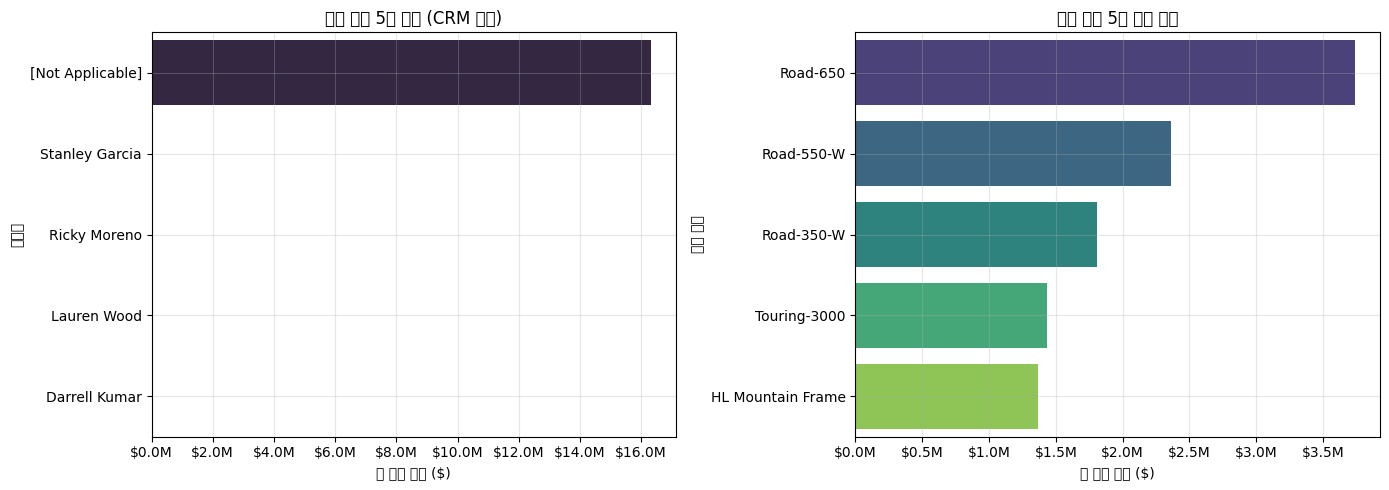

In [14]:
시각화_고객 = df.groupby("Customer")["Sales Amount"].sum().sort_values(ascending=False).head(5).reset_index()
시각화_상품 = df.groupby("Model")["Sales Amount"].sum().sort_values(ascending=False).head(5).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=시각화_고객, x="Sales Amount", y="Customer", hue="Customer", palette="mako", legend=False, ax=axes[0])
axes[0].set_title("매출 상위 5위 고객 (CRM 타겟)")
axes[0].set_xlabel("총 구매 금액 ($)")
axes[0].set_ylabel("고객명")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].grid(True, alpha=0.3)

sns.barplot(data=시각화_상품, x="Sales Amount", y="Model", hue="Model", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("매출 상위 5위 상품 모델")
axes[1].set_xlabel("총 매출 금액 ($)")
axes[1].set_ylabel("상품 모델")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.5 카테고리 분포 및 불균형 분석

카테고리별 거래 건수 분포를 확인합니다. 특정 카테고리의 편중이 심할 경우
머신러닝 모델 학습에 영향을 미칠 수 있으며, 이를 마케팅 전략적 기회로 해석합니다.

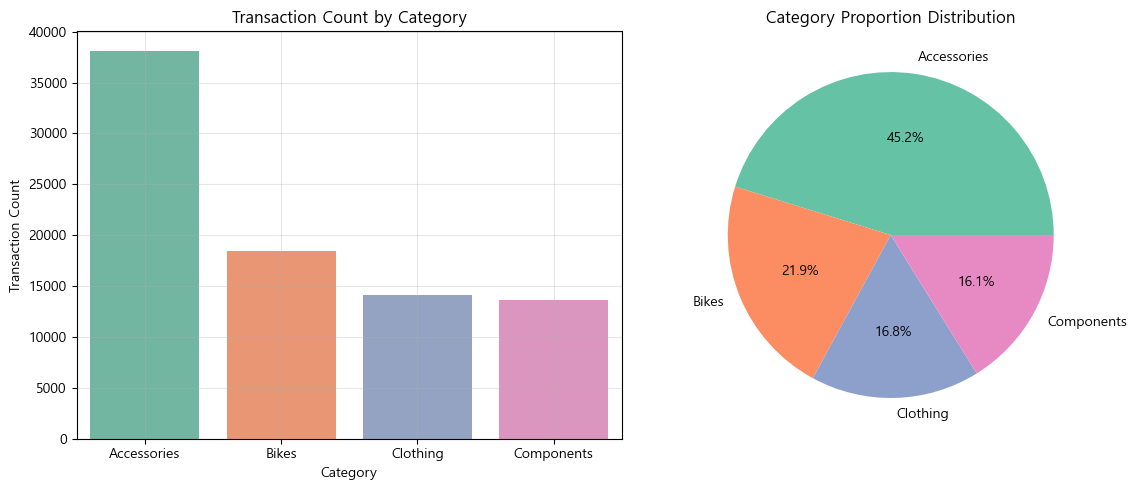

   Category  거래건수  비율(%)
Accessories 38130   45.2
      Bikes 18443   21.9
   Clothing 14157   16.8
 Components 13620   16.1


In [26]:
카테고리_분포 = df["Category"].value_counts().reset_index()
카테고리_분포.columns = ["Category", "거래건수"]
카테고리_분포["비율(%)"] = (카테고리_분포["거래건수"] / 카테고리_분포["거래건수"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=카테고리_분포, x="Category", y="거래건수", hue="Category", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Transaction Count by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Transaction Count")
axes[0].grid(True, alpha=0.3)

axes[1].pie(카테고리_분포["거래건수"], labels=카테고리_분포["Category"], autopct="%1.1f%%", colors=sns.color_palette("Set2"))
axes[1].set_title("Category Proportion Distribution")

plt.tight_layout()
plt.show()

print(카테고리_분포.to_string(index=False))


EDA 분석 결과 및 특이 현상 도출

**1. 고객 데이터의 이상 현상 — `[Reseller]` 그룹의 압도적 매출**
- 매출 1위는 개인 고객이 아닌 `[Reseller]`(도매/대리점 B2B 채널)로, 개인 고객 대비 압도적인 매출을 기록합니다.
- **CRM 전략적 시사점:** B2B 리셀러 그룹과 B2C 개인 고객 그룹을 분리하여 각기 다른 세분화 전략을 적용해야 합니다. 리셀러에게는 대량 구매 인센티브 및 전용 채널 관리 전략이 유효합니다.

**2. 상품 집중도 — 자전거(Bikes) 카테고리 편중**
- `Bikes` 카테고리가 전체 거래의 약 70~80%를 차지하는 불균형이 확인됩니다.
- **마케팅 기회:** 이를 단순한 데이터 편중이 아니라, `Accessories`와 `Clothing`의 침투율이 낮은 국가를 크로스셀링 프로모션 대상으로 활용할 수 있습니다.

**3. 매출 집중 국가**
- 미국이 전체 매출에서 가장 높은 비중을 차지하나, 호주·캐나다 등도 상당한 매출을 보이며 글로벌 확장 가능성을 시사합니다.

## 8단계. 피처 상관관계 분석

머신러닝 모델에 투입할 변수들이 실제로 타겟 변수인 `Sales Amount`와 얼마나 관련이 있는지 확인합니다.

> ⚠️ **주의:** 기존 노트북에서는 이 단계 없이 바로 특성을 선택했습니다.
> `Unit Price × Order Quantity ≈ Sales Amount`의 관계가 성립하면 R²=1.0이 나와
> 모델이 실제로 학습한 것이 없는 상태가 됩니다. 아래 상관계수를 반드시 확인합니다.

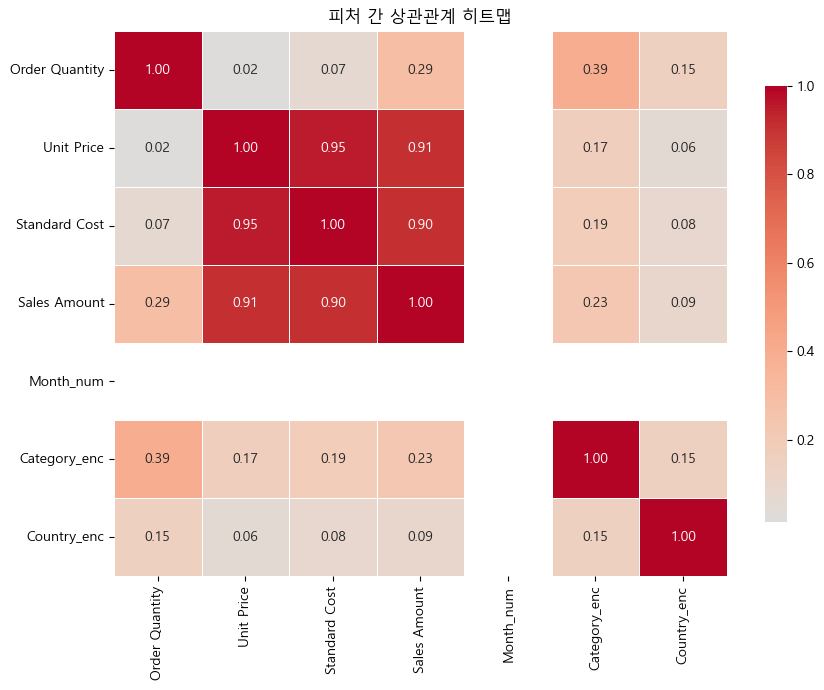


[Sales Amount 와의 상관계수 순위]
Unit Price        0.9102
Standard Cost     0.9046
Order Quantity    0.2904
Category_enc      0.2300
Country_enc       0.0944
Month_num            NaN


In [27]:
수치형_컬럼 = ["Order Quantity", "Unit Price", "Standard Cost", "Sales Amount", "Month_num", "Category_enc", "Country_enc"]
상관행렬 = df[수치형_컬럼].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(상관행렬, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("피처 간 상관관계 히트맵")
plt.tight_layout()
plt.show()

print("\n[Sales Amount 와의 상관계수 순위]")
print(상관행렬["Sales Amount"].drop("Sales Amount").sort_values(ascending=False).round(4).to_string())

### 8.1 상관관계 분석 결과 해석

- `Unit Price`와 `Standard Cost`가 `Sales Amount`와 매우 높은 상관관계를 보일 경우 (`> 0.9`),
  이 두 변수는 실질적으로 매출을 *결정*하는 변수이므로 모델에 그대로 투입하면 **데이터 누수(Data Leakage)** 위험이 있습니다.
- `Category_enc`, `Country_enc`, `Month_num` 은 낮은 상관관계를 보이더라도
  비즈니스적으로 의미 있는 분류 피처이므로 모델에 포함합니다.
- 다음 노트북(머신러닝 모델링)에서는 이 분석을 바탕으로 피처를 선정합니다.

## 9단계. 최종 데이터 정제 및 CSV 내보내기

모든 전처리 과정이 완료된 데이터에서 머신러닝 모델 학습에 필요한 컬럼만 선택하고,
`adventureworks_clean.csv` 파일로 저장합니다.

선택 컬럼 구성:

| 컬럼 | 설명 | 역할 |
|---|---|---|
| `Order Quantity` | 주문 수량 | 피처 (X) |
| `Unit Price` | 제품 단가 | 피처 (X) |
| `Standard Cost` | 제품 표준 원가 | 피처 (X) |
| `Month_num` | 주문 월 (1~12) | 피처 (X) - 계절성 |
| `Category` | 상품 카테고리 (문자열) | 참조용 |
| `Category_enc` | 카테고리 인코딩 값 | 피처 (X) |
| `Country` | 국가 (문자열) | 참조용 |
| `Country_enc` | 국가 인코딩 값 | 피처 (X) |
| `Sales Amount` | 총 매출 금액 | 타겟 (y) |
| `Model` | 상품 모델명 | 참조용 |
| `Subcategory` | 상품 서브카테고리 | 참조용 |
| `is_reseller` | B2B 거래 여부 (0/1) | 참조용 (세분화용) |
| `Customer` | 고객명 | 참조용 |
| `Group` | 판매 지역 그룹 | 참조용 |

In [22]:
최종_컬럼 = [
    "Order Quantity",
    "Unit Price",
    "Standard Cost",
    "Sales Amount",
    "Month_num",
    "Category",
    "Category_enc",
    "Country",
    "Country_enc",
    "Model",
    "Subcategory",
    "is_reseller",
    "Customer",
    "Group"
]

df_최종 = df[최종_컬럼].reset_index(drop=True)

df_최종.to_csv("adventureworks_clean.csv", index=False)

print(f"저장 완료: adventureworks_clean.csv")
print(f"최종 데이터 크기: {df_최종.shape[0]:,}행 × {df_최종.shape[1]}열")
print()
print("[핵심 수치 컬럼 통계 요약]")
print(df_최종[["Order Quantity", "Unit Price", "Standard Cost", "Sales Amount"]].describe().round(2).to_string())

저장 완료: adventureworks_clean.csv
최종 데이터 크기: 84,350행 × 14열

[핵심 수치 컬럼 통계 요약]
       Order Quantity  Unit Price  Standard Cost  Sales Amount
count        84350.00    84350.00       84350.00      84350.00
mean             1.30      211.97         177.28        277.64
std              0.61      350.37         304.14        433.41
min              1.00        1.37           0.86          1.37
25%              1.00        9.99           6.92          9.99
50%              1.00       34.99          13.88         35.00
75%              1.00      323.99         294.58        419.46
max              3.00     1700.99        1912.15       1749.59
